# Week 15 — Tuesday (Jul 2): DCGAN & StyleGAN

## Learning Objectives
- Understand why fully-connected GANs fail on images and how DCGAN fixes this
- Know the 5 architectural rules from the DCGAN paper
- Implement DCGAN from scratch using ConvTranspose2d
- Understand StyleGAN's key innovations: mapping network, AdaIN, style control
- Compare FC-GAN vs DCGAN output quality

## Key Concepts
1. **DCGAN** — Deep Convolutional GAN (Radford et al., 2015) — strided convolutions instead of pooling/FC
2. **ConvTranspose2d** — learnable upsampling (fractional-strided convolution)
3. **BatchNorm in G and D** — stabilises training, but NOT on G output or D input layers
4. **LeakyReLU in D** — allows small negative gradients, prevents dying neurons
5. **StyleGAN** — maps z to intermediate W space, injects style at each layer via AdaIN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 15 — DCGAN & StyleGAN')

PyTorch 2.12.0+cpu | Device: cpu
Week 15 — DCGAN & StyleGAN


## Section 1: Why FC-GAN Fails on Images

The Vanilla GAN uses fully-connected layers — every output pixel is independently predicted. This means:
- **No spatial structure**: the network doesn't know pixels are arranged in a 2D grid
- **Parameter explosion**: a 64×64 image has 4096 pixels — a dense layer connecting everything is huge
- **No local patterns**: cannot learn local features (edges, textures) shared across positions

DCGAN solves this by replacing linear layers with **convolutions**, which naturally capture spatial structure.

## Section 2: The 5 DCGAN Rules (from the original paper)

```
Rule 1: Replace pooling with STRIDED CONVOLUTIONS (D) and FRACTIONAL-STRIDED CONV (G)
        → Learn spatial downsampling/upsampling instead of using fixed pool

Rule 2: Use BATCH NORMALISATION in both G and D
        → Stabilises training; but NOT on G's output layer or D's input layer

Rule 3: REMOVE fully-connected hidden layers for deeper architectures
        → Pure convolutional pipeline

Rule 4: Use RELU in G for all layers EXCEPT output (use Tanh)
        → Tanh maps output to [-1,1] matching normalised real images

Rule 5: Use LEAKY RELU in D for all layers
        → Allows small gradient for negative activations, no dead neurons
```

### ConvTranspose2d — The Upsampling Layer
```
Input feature map:  2×2
ConvTranspose2d(kernel=4, stride=2, padding=1)
Output feature map: 4×4

Each input cell "expands" to a kernel-sized region — the reverse of a strided conv.
Learnable parameters = in_ch × out_ch × k × k (same as Conv2d, just applied in reverse)
```

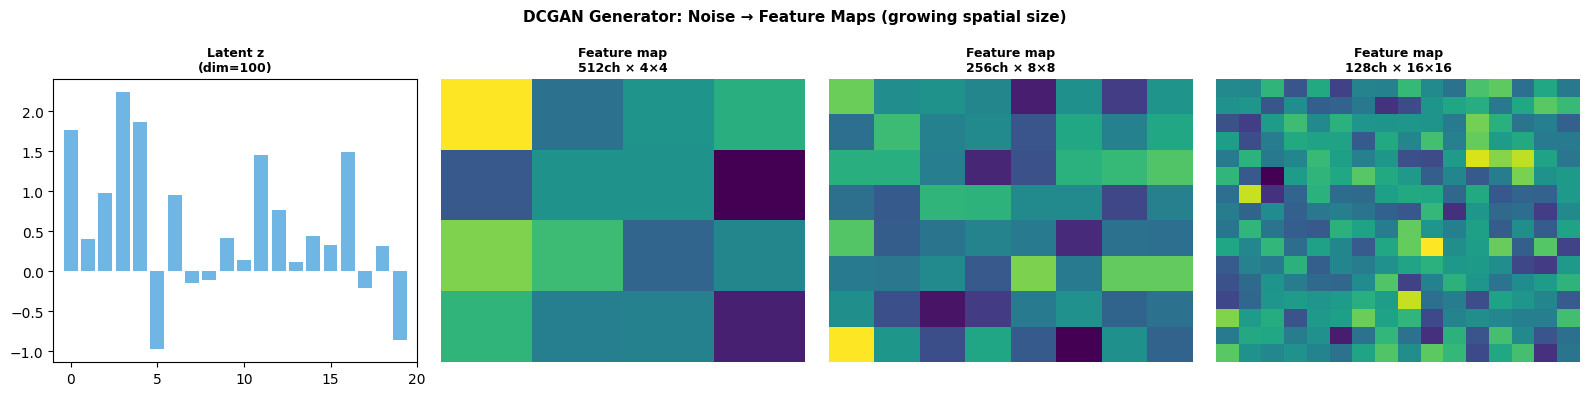

Saved dcgan_architecture.png


In [2]:
# ── Visualise ConvTranspose2d upsampling ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Show how spatial size grows through G
sizes = [(1,1,100), (1,512,4), (1,256,8), (1,128,16)]
labels = ['z\n(100,)', 'Conv\nT\n512→4×4', 'Conv\nT\n256→8×8', 'Conv\nT\n128→16×16']
for i, ((b,c,s), lbl) in enumerate(zip(sizes, labels)):
    np.random.seed(i*7)
    if s == 100:
        feat = np.random.randn(s)
        axes[i].bar(range(min(s,20)), feat[:20], color='#3498db', alpha=0.7)
        axes[i].set_title(f'Latent z\n(dim={s})', fontweight='bold', fontsize=9)
        axes[i].set_xlim(-1,20)
    else:
        feat = np.random.randn(s, s)
        axes[i].imshow(feat, cmap='viridis', aspect='auto')
        axes[i].set_title(f'Feature map\n{c}ch × {s}×{s}', fontweight='bold', fontsize=9)
    axes[i].axis('off') if s != 100 else None

plt.suptitle('DCGAN Generator: Noise → Feature Maps (growing spatial size)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('dcgan_architecture.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved dcgan_architecture.png')

In [3]:
# ── DCGAN Generator ────────────────────────────────────────────────────────────
class DCGenerator(nn.Module):
    """
    DCGAN Generator for 32×32 images.
    z (z_dim,) → Linear → reshape (512,2,2) → ConvTranspose chain → (1,32,32)
    """
    def __init__(self, z_dim=100, img_channels=1):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(z_dim, 512*2*2),
            nn.ReLU(inplace=True)
        )
        self.conv = nn.Sequential(
            # 512 × 2×2 → 256 × 4×4
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            # 256 × 4×4 → 128 × 8×8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            # 128 × 8×8 → 64 × 16×16
            nn.ConvTranspose2d(128,  64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            # 64 × 16×16 → img_ch × 32×32   (NO BatchNorm on output layer)
            nn.ConvTranspose2d( 64, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()  # Rule 4: Tanh on output
        )

    def forward(self, z):
        x = self.project(z).view(-1, 512, 2, 2)
        return self.conv(x)


class DCDiscriminator(nn.Module):
    """
    DCGAN Discriminator for 32×32 images.
    (1,32,32) → strided conv chain → flatten → Linear → scalar
    """
    def __init__(self, img_channels=1):
        super().__init__()
        self.net = nn.Sequential(
            # 1 × 32×32 → 64 × 16×16   (NO BatchNorm on input layer)
            nn.Conv2d(img_channels, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),  # Rule 5: LeakyReLU in D
            # 64 × 16×16 → 128 × 8×8
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            # 128 × 8×8 → 256 × 4×4
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            # 256 × 4×4 → 512 × 2×2
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            # Flatten + classify
            nn.Flatten(),
            nn.Linear(512*2*2, 1), nn.Sigmoid()
        )

    def forward(self, x): return self.net(x)


G_dc = DCGenerator().to(DEVICE)
D_dc = DCDiscriminator().to(DEVICE)
print('DCGAN Architecture:')
print(f'  Generator     params: {sum(p.numel() for p in G_dc.parameters()):,}')
print(f'  Discriminator params: {sum(p.numel() for p in D_dc.parameters()):,}')
z_t  = torch.randn(4, 100).to(DEVICE)
fake = G_dc(z_t)
print(f'  z {tuple(z_t.shape)} → G → {tuple(fake.shape)} → D → {tuple(D_dc(fake).shape)}')

DCGAN Architecture:
  Generator     params: 2,961,280
  Discriminator params: 2,757,377
  z (4, 100) → G → (4, 1, 32, 32) → D → (4, 1)


In [4]:
# ── MNIST at 32×32 ────────────────────────────────────────────────────────────
Z_DIM   = 100
N_EPOCHS= 8
LR      = 2e-4

tf32 = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
full_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tf32)
train_ds = Subset(full_ds, list(range(2000)))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
print(f'Dataset: {len(train_ds)} samples at 32×32')

criterion  = nn.BCELoss()
opt_G_dc   = torch.optim.Adam(G_dc.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D_dc   = torch.optim.Adam(D_dc.parameters(), lr=LR, betas=(0.5, 0.999))
fixed_z    = torch.randn(16, Z_DIM).to(DEVICE)
history_dc = {'d_loss':[], 'g_loss':[], 'd_real':[], 'd_fake':[]}

for epoch in range(1, N_EPOCHS+1):
    ep_d, ep_g, ep_dr, ep_df = [], [], [], []
    for real_imgs, _ in train_dl:
        real_imgs = real_imgs.to(DEVICE)
        bs = real_imgs.size(0)
        # Train D
        z    = torch.randn(bs, Z_DIM).to(DEVICE)
        fake = G_dc(z).detach()
        d_real = D_dc(real_imgs)
        d_fake = D_dc(fake)
        loss_D = (criterion(d_real, torch.full((bs,1),0.9).to(DEVICE)) +
                  criterion(d_fake, torch.zeros(bs,1).to(DEVICE)))
        opt_D_dc.zero_grad(); loss_D.backward(); opt_D_dc.step()
        # Train G
        z    = torch.randn(bs, Z_DIM).to(DEVICE)
        fake = G_dc(z)
        loss_G = criterion(D_dc(fake), torch.ones(bs,1).to(DEVICE))
        opt_G_dc.zero_grad(); loss_G.backward(); opt_G_dc.step()

        ep_d.append(loss_D.item()); ep_g.append(loss_G.item())
        ep_dr.append(d_real.mean().item()); ep_df.append(d_fake.mean().item())

    history_dc['d_loss'].append(np.mean(ep_d)); history_dc['g_loss'].append(np.mean(ep_g))
    history_dc['d_real'].append(np.mean(ep_dr)); history_dc['d_fake'].append(np.mean(ep_df))
    print(f'Ep {epoch:2d}/{N_EPOCHS} | D:{history_dc["d_loss"][-1]:.4f} '
          f'G:{history_dc["g_loss"][-1]:.4f} '
          f'D(real)={history_dc["d_real"][-1]:.3f} D(fake)={history_dc["d_fake"][-1]:.3f}')
print('DCGAN training done.')

Dataset: 2000 samples at 32×32


Ep  1/8 | D:0.5334 G:6.2286 D(real)=0.843 D(fake)=0.103


Ep  2/8 | D:0.3513 G:6.8277 D(real)=0.898 D(fake)=0.008


Ep  3/8 | D:0.3392 G:6.8631 D(real)=0.896 D(fake)=0.005


Ep  4/8 | D:0.3377 G:7.2799 D(real)=0.898 D(fake)=0.004


Ep  5/8 | D:0.4048 G:8.7451 D(real)=0.894 D(fake)=0.012


Ep  6/8 | D:0.3552 G:8.9726 D(real)=0.890 D(fake)=0.012


Ep  7/8 | D:0.3348 G:7.0640 D(real)=0.894 D(fake)=0.006


Ep  8/8 | D:0.5696 G:7.3098 D(real)=0.870 D(fake)=0.039
DCGAN training done.


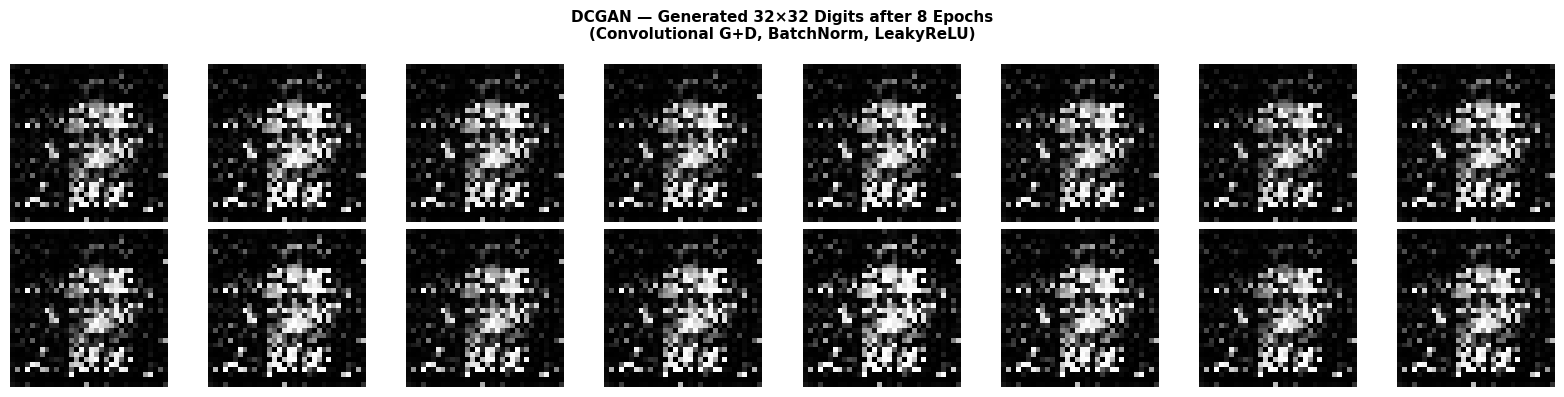

Saved dcgan_generated.png


In [5]:
# ── DCGAN generated samples ───────────────────────────────────────────────────
G_dc.eval()
with torch.no_grad():
    dc_imgs = G_dc(fixed_z).cpu().squeeze(1)  # (16, 32, 32)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    axes[i//8, i%8].imshow(dc_imgs[i].numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[i//8, i%8].axis('off')
plt.suptitle(f'DCGAN — Generated 32×32 Digits after {N_EPOCHS} Epochs\n'
             f'(Convolutional G+D, BatchNorm, LeakyReLU)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('dcgan_generated.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved dcgan_generated.png')

## Section 3: StyleGAN — Style-based Generator

Karras et al. (NVIDIA, 2019) — state of the art for high-resolution face generation.

### Key Problems StyleGAN Solves
In a standard GAN: the latent code z goes directly into the first layer. This means:
- Different aspects of the image (pose, colour, texture, fine details) are all entangled in z
- You can't independently control coarse vs fine features

### StyleGAN Architecture
```
  z (latent)                     W (intermediate)
  512-dim ──► Mapping Network ──► 512-dim
              (8× FC layers)       │
                                   │ AdaIN at every resolution
  Learned                         ▼
  const 4×4 ──► 4×4 ──► 8×8 ──► 16×16 ──► ... ──► 1024×1024
                 ↑        ↑        ↑
               style    style    style
               (coarse) (mid)   (fine)
```

### Why Map z → W?
- The Z space is a sphere (uniform distribution) — hard to control individual features
- The W space is learned to be **disentangled** — each dimension controls one attribute
- Result: interpolating in W gives smooth, meaningful transitions

### AdaIN — Adaptive Instance Normalisation
$$\text{AdaIN}(x_i, y) = y_{s,i} \cdot \frac{x_i - \mu(x_i)}{\sigma(x_i)} + y_{b,i}$$
- $x_i$: feature map channel $i$ from the synthesis network
- $y_{s,i}, y_{b,i}$: scale and bias derived from the style vector W via a learned affine transform
- **Effect**: the style vector controls the mean and variance (statistics) of every feature map → controls texture, colour, fine structure at each scale

MiniStyleGenerator | params: 130,145
  z (4, 64) → W → synthesis → (4, 1, 32, 32)


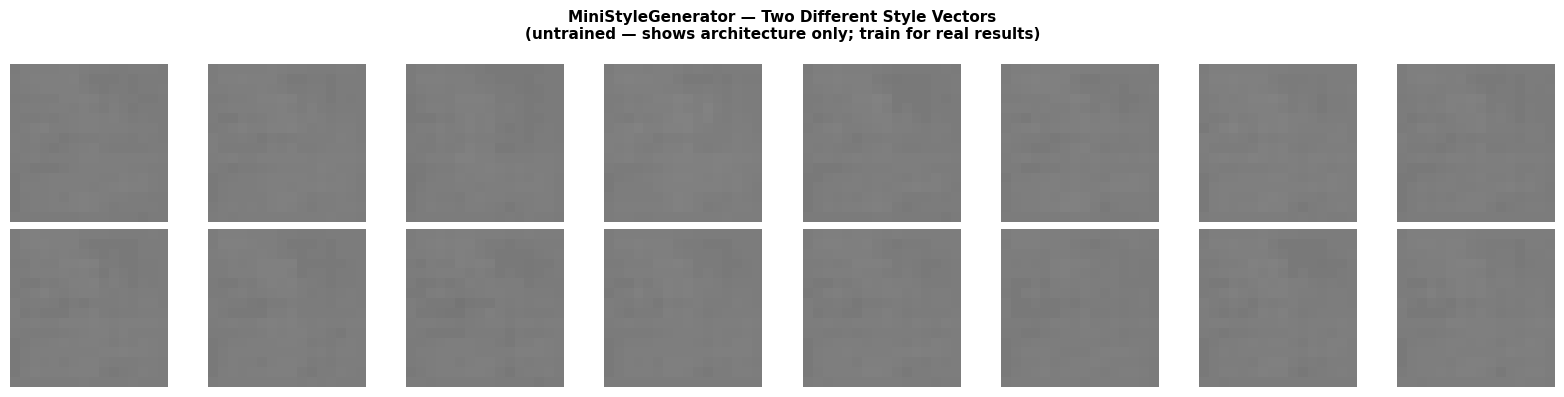

Saved stylegan_demo.png


In [6]:
# ── AdaIN implementation ───────────────────────────────────────────────────────
class AdaIN(nn.Module):
    """Adaptive Instance Normalisation — injects style into feature maps."""
    def __init__(self, channels, w_dim):
        super().__init__()
        self.norm  = nn.InstanceNorm2d(channels, affine=False)
        self.style = nn.Linear(w_dim, channels * 2)  # predict scale + bias

    def forward(self, x, w):
        # x: (B, C, H, W)  w: (B, w_dim)
        style = self.style(w).unsqueeze(2).unsqueeze(3)  # (B, 2C, 1, 1)
        scale, bias = style.chunk(2, dim=1)              # each (B, C, 1, 1)
        return scale * self.norm(x) + bias


class MappingNetwork(nn.Module):
    """StyleGAN mapping network: z → W (8 FC layers with LeakyReLU)."""
    def __init__(self, z_dim=64, w_dim=64, depth=4):
        super().__init__()
        layers = []
        for i in range(depth):
            layers += [nn.Linear(z_dim if i==0 else w_dim, w_dim), nn.LeakyReLU(0.2)]
        self.net = nn.Sequential(*layers)
    def forward(self, z): return self.net(z)


class StyleBlock(nn.Module):
    """One resolution block in the StyleGAN synthesis network."""
    def __init__(self, in_ch, out_ch, w_dim):
        super().__init__()
        self.conv  = nn.Conv2d(in_ch, out_ch, 3, 1, 1)
        self.adain = AdaIN(out_ch, w_dim)
        self.act   = nn.LeakyReLU(0.2)

    def forward(self, x, w):
        x = self.conv(x); x = self.adain(x, w); return self.act(x)


class MiniStyleGenerator(nn.Module):
    """Simplified StyleGAN-style generator for concept demo."""
    def __init__(self, z_dim=64, w_dim=64, img_channels=1):
        super().__init__()
        self.mapping = MappingNetwork(z_dim, w_dim)
        self.const   = nn.Parameter(torch.randn(1, 128, 4, 4))  # learned constant
        self.block1  = StyleBlock(128, 64, w_dim)
        self.block2  = StyleBlock(64,  32, w_dim)
        self.block3  = StyleBlock(32,  16, w_dim)
        self.out     = nn.Conv2d(16, img_channels, 1)

    def forward(self, z):
        w = self.mapping(z)                                         # z → W
        x = self.const.expand(z.size(0), -1, -1, -1)               # (B,128,4,4)
        x = F.interpolate(self.block1(x, w), scale_factor=2)       # → 8×8
        x = F.interpolate(self.block2(x, w), scale_factor=2)       # → 16×16
        x = F.interpolate(self.block3(x, w), scale_factor=2)       # → 32×32
        return torch.tanh(self.out(x))


# Demo
style_G = MiniStyleGenerator().to(DEVICE)
z_demo  = torch.randn(4, 64).to(DEVICE)
out     = style_G(z_demo)
print(f'MiniStyleGenerator | params: {sum(p.numel() for p in style_G.parameters()):,}')
print(f'  z {tuple(z_demo.shape)} → W → synthesis → {tuple(out.shape)}')

# Show style mixing: take style from two different z vectors
style_G.eval()
z1 = torch.randn(8, 64).to(DEVICE)
z2 = torch.randn(8, 64).to(DEVICE)
with torch.no_grad():
    imgs_z1 = style_G(z1).cpu().squeeze(1)
    imgs_z2 = style_G(z2).cpu().squeeze(1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0,i].imshow(imgs_z1[i].numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[1,i].imshow(imgs_z2[i].numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[0,i].axis('off'); axes[1,i].axis('off')
axes[0,0].set_ylabel('Style A\n(z₁)', fontsize=9, fontweight='bold')
axes[1,0].set_ylabel('Style B\n(z₂)', fontsize=9, fontweight='bold')
plt.suptitle('MiniStyleGenerator — Two Different Style Vectors\n'
             '(untrained — shows architecture only; train for real results)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('stylegan_demo.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved stylegan_demo.png')

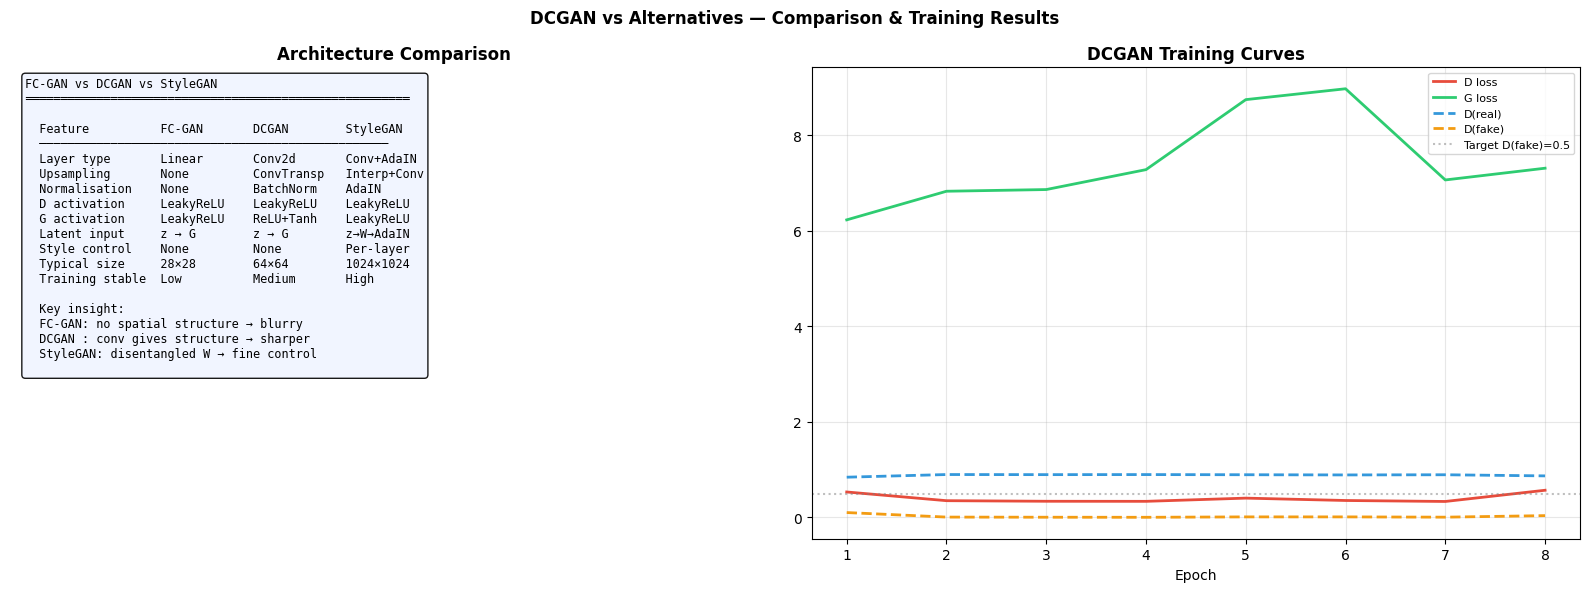

Saved gan_comparison.png


In [7]:
# ── FC-GAN vs DCGAN comparison summary ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Architecture comparison table
table_text = (
    'FC-GAN vs DCGAN vs StyleGAN\n'
    '══════════════════════════════════════════════════════\n\n'
    '  Feature          FC-GAN       DCGAN        StyleGAN\n'
    '  ─────────────────────────────────────────────────\n'
    '  Layer type       Linear       Conv2d       Conv+AdaIN\n'
    '  Upsampling       None         ConvTransp   Interp+Conv\n'
    '  Normalisation    None         BatchNorm    AdaIN\n'
    '  D activation     LeakyReLU    LeakyReLU    LeakyReLU\n'
    '  G activation     LeakyReLU    ReLU+Tanh    LeakyReLU\n'
    '  Latent input     z → G        z → G        z→W→AdaIN\n'
    '  Style control    None         None         Per-layer\n'
    '  Typical size     28×28        64×64        1024×1024\n'
    '  Training stable  Low          Medium       High\n\n'
    '  Key insight:\n'
    '  FC-GAN: no spatial structure → blurry\n'
    '  DCGAN : conv gives structure → sharper\n'
    '  StyleGAN: disentangled W → fine control\n'
)
axes[0].text(0.02, 0.98, table_text, va='top', ha='left',
             fontfamily='monospace', fontsize=8.5, transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.9))
axes[0].set_title('Architecture Comparison', fontweight='bold'); axes[0].axis('off')

# DCGAN training curves
ep = range(1, N_EPOCHS+1)
axes[1].plot(ep, history_dc['d_loss'], label='D loss', color='#e74c3c', lw=2)
axes[1].plot(ep, history_dc['g_loss'], label='G loss', color='#2ecc71', lw=2)
axes[1].plot(ep, history_dc['d_real'], label='D(real)', color='#3498db', lw=2, ls='--')
axes[1].plot(ep, history_dc['d_fake'], label='D(fake)', color='#f39c12', lw=2, ls='--')
axes[1].axhline(0.5, color='grey', ls=':', alpha=0.5, label='Target D(fake)=0.5')
axes[1].set_title('DCGAN Training Curves', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('DCGAN vs Alternatives — Comparison & Training Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gan_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved gan_comparison.png')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **DCGAN Rule 1** | Replace pooling with strided conv (D) and ConvTranspose2d (G) — learnable spatial sampling |
| **DCGAN Rule 2** | BatchNorm in both G and D — but NOT on G's output or D's input |
| **ConvTranspose2d** | Reverse of strided conv — upsamples feature maps with learnable parameters |
| **LeakyReLU in D** | Slope 0.2 for negative values — no dead neurons, smoother gradients for D |
| **StyleGAN W space** | Mapping network z→W learns a disentangled space — each dimension controls one attribute |
| **AdaIN** | Style vector controls scale+bias of every feature map channel — injects texture at each scale |
| **Coarse/mid/fine** | Low-resolution layers → pose/shape; mid → features; high → colour/texture |
| **beta1=0.5 in Adam** | Standard for GAN training — lower momentum decay for more stable adversarial updates |

### Exercises
1. Remove BatchNorm from DCGAN and observe training instability.
2. Replace LeakyReLU with ReLU in the discriminator — does training collapse faster?
3. Implement spectral normalisation on the discriminator and compare stability.
4. Try latent interpolation: take two z vectors, linearly blend them, and visualise the transition.
5. Add an extra ConvTranspose2d stage to generate 64×64 images instead of 32×32.